# Simulated Annealing — User Input + Iteration Path

Enter **a, b, c, x0, T0, alpha and T_min** when prompted. The graph shows the actual state after every iteration, connected in sequence with iteration numbers and arrows.

In [9]:
# USER INPUT
a = float(input('Enter a: '))
b = float(input('Enter b: '))
c = float(input('Enter c: '))
x0 = float(input('Enter x0: '))
T0 = float(input('Enter T0: '))
alpha = float(input('Enter alpha: '))
T_min = float(input('Enter T_min: '))

print('\nParameters entered:')
print(f'a = {a}, b = {b}, c = {c}')
print(f'x0 = {x0}, T0 = {T0}, alpha = {alpha}, T_min = {T_min}')


Parameters entered:
a = 1.0, b = -6.0, c = 13.0
x0 = 1.0, T0 = 10.0, alpha = 0.5, T_min = 1.0


In [ ]:
import math
import random
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt

# Fixed settings — everything other than the seven requested parameters remains fixed
neighbour_step = 1
iterations_per_temperature = 1
seed = 42

def f(x):
    return a*x**2 + b*x + c

random.seed(seed)
np.random.seed(seed)

# Simulated Annealing
current_x = x0
current_value = f(current_x)
temperature = T0
history = []
iteration = 0

# Store initial state as iteration 0
history.append({
    'Iteration': 0,
    'Temperature': temperature,
    'Current x': current_x,
    'Current f(x)': current_value,
    'Candidate x': np.nan,
    'Candidate f(x)': np.nan,
    'Delta': np.nan,
    'Acceptance Probability': np.nan,
    'Accepted': True
})
while temperature >= T_min:
    for _ in range(iterations_per_temperature):
        iteration += 1
        candidate_x = current_x + random.choice([-neighbour_step, neighbour_step])
        candidate_value = f(candidate_x)
        delta = candidate_value - current_value

        if delta <= 0:
            accepted = True
            probability = 1.0
        else:
            probability = math.exp(-delta / temperature)
            accepted = random.random() < probability

        # Record the state AFTER the acceptance decision.
        if accepted:
            current_x = candidate_x
            current_value = candidate_value

        history.append({
            'Iteration': iteration,
            'Temperature': temperature,
            'Current x': current_x,
            'Current f(x)': current_value,
            'Candidate x': candidate_x,
            'Candidate f(x)': candidate_value,
            'Delta': delta,
            'Acceptance Probability': probability,
            'Accepted': accepted
        })

    temperature *= alpha

results = pd.DataFrame(history)
print(f'Total iterations: {iteration}')
print(f'Final x: {current_x}')
print(f'Final f(x): {current_value}')
results

Total iterations: 5
Final x: 1.0
Final f(x): 8.0


,Iteration,Temperature,Current x,Current f(x),Candidate x,Candidate f(x),Delta,Acceptance Probability,Accepted
0,0,10.00,1.0,8.0,NaN,NaN,NaN,NaN,True
1,2,10.00,0.0,13.0,0.0,13.0,5.0,0.606531,True
2,3,5.00,1.0,8.0,1.0,8.0,-5.0,1.000000,True
3,4,2.50,1.0,8.0,0.0,13.0,5.0,0.135335,False
4,5,1.25,1.0,8.0,0.0,13.0,5.0,0.018316,False


In [11]:
# Final result
print('Simulated Annealing Result')
print('--------------------------')
print(f'Best x found = {current_x}')
print(f'Minimum f(x) = {current_value}')

if a != 0:
    analytical_x = -b / (2*a)
    print(f'Analytical minimum x = {analytical_x}')
    print(f'Analytical minimum f(x) = {f(analytical_x)}')

Simulated Annealing Result
--------------------------
Best x found = 1.0
Minimum f(x) = 8.0
Analytical minimum x = 3.0
Analytical minimum f(x) = 4.0


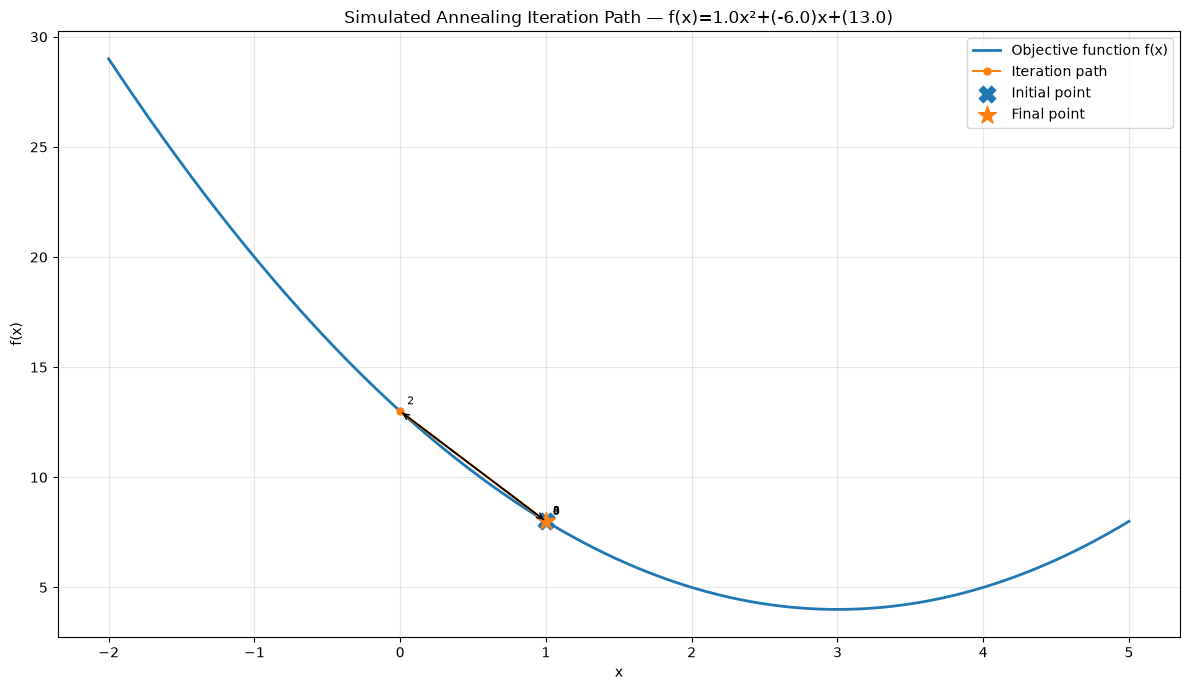

In [12]:
# GRAPH — ACTUAL ITERATION PATH
# Every plotted point is the state AFTER that iteration.

path_x = results['Current x'].to_numpy()
path_y = results['Current f(x)'].to_numpy()

xmin = path_x.min() - 2
xmax = path_x.max() + 2
if a != 0:
    analytical_x = -b/(2*a)
    xmin = min(xmin, analytical_x - 2)
    xmax = max(xmax, analytical_x + 2)

x_values = np.linspace(xmin, xmax, 600)
y_values = f(x_values)

plt.figure(figsize=(12, 7))
plt.plot(x_values, y_values, linewidth=2, label='Objective function f(x)')

# Connect the actual iteration states in chronological order
plt.plot(path_x, path_y, marker='o', markersize=5, linewidth=1.5, label='Iteration path')

# Direction arrows: iteration i -> iteration i+1
for i in range(len(results)-1):
    x1, y1 = path_x[i], path_y[i]
    x2, y2 = path_x[i+1], path_y[i+1]
    if x1 != x2 or y1 != y2:
        plt.annotate('', xy=(x2,y2), xytext=(x1,y1),
                     arrowprops=dict(arrowstyle='->', linewidth=1))

# Initial and final points
plt.scatter(x0, f(x0), s=140, marker='X', label='Initial point')
plt.scatter(current_x, current_value, s=180, marker='*', label='Final point')

# Iteration labels
for i, row in results.iterrows():
    plt.annotate(str(int(row['Iteration'])),
                 (row['Current x'], row['Current f(x)']),
                 xytext=(5,5), textcoords='offset points', fontsize=8)

plt.xlabel('x')
plt.ylabel('f(x)')
plt.title(f'Simulated Annealing Iteration Path — f(x)={a}x²+({b})x+({c})')
plt.grid(True, alpha=0.3)
plt.legend()
plt.tight_layout()
plt.show()